In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Python 环境已准备好")

Python 环境已准备好


In [5]:
# 读取万科财务数据 Excel

文件路径 = "../data/raw/万科财务数据.xlsx"
工作表名称 = "财务数据"

财务数据 = pd.read_excel(文件路径, sheet_name=工作表名称)

# 查看前几行数据
财务数据.head()

,年份,营业收入,营业成本,毛利润,营业利润,净利润,归母净利润,货币资金,流动资产,总资产,...,应付债券,总有息债务,股东权益合计,经营活动现金流量净额,投资活动现金流量净额,筹资活动现金流量净额,利息费用,未分配利润,盈余公积,留存收益
0,2021,4527.977740,3539.771380,988.206360,525.309972,380.695270,225.240334,1493.524443,16002.683073,19386.381287,...,530.205717,2696.872856,3927.727765,41.131609,-262.807862,-231.037675,78.613467,926.984441,1111.865206,2038.849647
1,2022,5038.383674,4053.192870,985.190804,520.290464,376.125588,226.885518,1372.076349,14153.563800,17578.049359,...,688.155702,3176.442303,4056.368300,27.504495,-130.302712,34.389189,58.865518,980.138928,1177.436771,2157.575698
2,2023,4657.390767,3947.838595,709.552172,292.517021,204.555584,121.626844,998.137554,11502.600624,15048.501721,...,598.710159,3236.255475,4029.335309,39.123239,-46.156421,-368.131643,57.374735,936.163019,1262.275369,2198.438387
3,2024,3431.764407,3082.648714,349.115693,-456.437963,-487.039344,-494.784292,881.628650,9175.120769,12862.598598,...,241.131323,2347.652132,3388.546625,-128.408880,23.832648,-74.999487,74.466934,441.378727,1262.275369,1703.654095
4,2025,2334.327690,2113.472918,220.854772,-709.990444,-918.100911,-885.564705,672.409497,6973.738540,10206.228315,...,112.953487,2120.249638,2358.600580,58.583620,12.166905,-75.002093,85.015087,-444.185978,1262.275369,818.089390


In [6]:
# 查看所有列名

print("数据列名：")
for 列名 in 财务数据.columns:
    print(列名)

数据列名：
年份
营业收入
营业成本
毛利润
营业利润
净利润
归母净利润
货币资金
流动资产
总资产
流动负债
总负债
短期借款
一年内到期的非流动负债
长期借款
应付债券
总有息债务
股东权益合计
经营活动现金流量净额
投资活动现金流量净额
筹资活动现金流量净额
利息费用
未分配利润
盈余公积
留存收益


In [7]:
# 检查数据基本情况

print("数据行数和列数：")
print(财务数据.shape)

print("\n缺失值检查：")
print(财务数据.isna().sum())

数据行数和列数：
(5, 25)

缺失值检查：
年份             0
营业收入           0
营业成本           0
毛利润            0
营业利润           0
净利润            0
归母净利润          0
货币资金           0
流动资产           0
总资产            0
流动负债           0
总负债            0
短期借款           0
一年内到期的非流动负债    0
长期借款           0
应付债券           0
总有息债务          0
股东权益合计         0
经营活动现金流量净额     0
投资活动现金流量净额     0
筹资活动现金流量净额     0
利息费用           0
未分配利润          0
盈余公积           0
留存收益           0
dtype: int64


In [8]:
# 查看年份范围

print("年份范围：")
print(财务数据["年份"].min(), "-", 财务数据["年份"].max())

print("\n数据单位：亿元")

年份范围：
2021 - 2025

数据单位：亿元


In [10]:
# 清理列名前后可能存在的空格
财务数据.columns = 财务数据.columns.astype(str).str.strip()

# 复制一份数据，避免直接改动原始数据
财务分析结果 = 财务数据.copy()

# =========================
# 1. 成长能力
# =========================
财务分析结果["营业收入增长率"] = 财务分析结果["营业收入"].pct_change()

# =========================
# 2. 盈利能力
# =========================
财务分析结果["毛利率"] = 财务分析结果["毛利润"] / 财务分析结果["营业收入"]
财务分析结果["营业利润率"] = 财务分析结果["营业利润"] / 财务分析结果["营业收入"]
财务分析结果["净利率"] = 财务分析结果["净利润"] / 财务分析结果["营业收入"]
财务分析结果["归母净利率"] = 财务分析结果["归母净利润"] / 财务分析结果["营业收入"]

# =========================
# 3. 回报能力
# =========================
财务分析结果["总资产回报率ROA"] = 财务分析结果["净利润"] / 财务分析结果["总资产"]
财务分析结果["净资产收益率ROE"] = 财务分析结果["净利润"] / 财务分析结果["股东权益合计"]

# =========================
# 4. 偿债能力与杠杆
# =========================
财务分析结果["资产负债率"] = 财务分析结果["总负债"] / 财务分析结果["总资产"]
财务分析结果["流动比率"] = 财务分析结果["流动资产"] / 财务分析结果["流动负债"]

# 短期有息债务 = 短期借款 + 一年内到期的非流动负债
财务分析结果["短期有息债务"] = (
    财务分析结果["短期借款"] + 财务分析结果["一年内到期的非流动负债"]
)

财务分析结果["现金短债比"] = 财务分析结果["货币资金"] / 财务分析结果["短期有息债务"]

# 总有息债务压力
财务分析结果["总有息债务占总资产比例"] = 财务分析结果["总有息债务"] / 财务分析结果["总资产"]

# =========================
# 5. 现金流质量
# =========================
财务分析结果["经营现金流净利润比"] = (
    财务分析结果["经营活动现金流量净额"] / 财务分析结果["净利润"]
)

# =========================
# 6. 利息压力与留存收益
# =========================
财务分析结果["利息费用率"] = 财务分析结果["利息费用"] / 财务分析结果["营业收入"]
财务分析结果["留存收益占股东权益比例"] = 财务分析结果["留存收益"] / 财务分析结果["股东权益合计"]

财务分析结果

,年份,营业收入,营业成本,毛利润,营业利润,净利润,归母净利润,货币资金,流动资产,总资产,...,总资产回报率ROA,净资产收益率ROE,资产负债率,流动比率,短期有息债务,现金短债比,总有息债务占总资产比例,经营现金流净利润比,利息费用率,留存收益占股东权益比例
0,2021,4527.977740,3539.771380,988.206360,525.309972,380.695270,225.240334,1493.524443,16002.683073,19386.381287,...,0.019637,0.096925,0.797398,1.220232,623.444349,2.395602,0.139112,0.108043,0.017362,0.519091
1,2022,5038.383674,4053.192870,985.190804,520.290464,376.125588,226.885518,1372.076349,14153.563800,17578.049359,...,0.021397,0.092725,0.769237,1.313188,680.553796,2.016117,0.180705,0.073126,0.011683,0.531898
2,2023,4657.390767,3947.838595,709.552172,292.517021,204.555584,121.626844,998.137554,11502.600624,15048.501721,...,0.013593,0.050767,0.732243,1.399709,659.903889,1.512550,0.215055,0.191260,0.012319,0.545608
3,2024,3431.764407,3082.648714,349.115693,-456.437963,-487.039344,-494.784292,881.628650,9175.120769,12862.598598,...,-0.037865,-0.143731,0.736558,1.275985,1256.709635,0.701537,0.182518,0.263652,0.021699,0.502768
4,2025,2334.327690,2113.472918,220.854772,-709.990444,-918.100911,-885.564705,672.409497,6973.738540,10206.228315,...,-0.089955,-0.389257,0.768906,1.233858,1104.886434,0.608578,0.207741,-0.063810,0.036420,0.346854


In [11]:
# 提取核心财务比率表

财务比率表 = 财务分析结果[
    [
        "年份",
        "营业收入增长率",
        "毛利率",
        "营业利润率",
        "净利率",
        "归母净利率",
        "总资产回报率ROA",
        "净资产收益率ROE",
        "资产负债率",
        "流动比率",
        "现金短债比",
        "总有息债务占总资产比例",
        "经营现金流净利润比",
        "利息费用率",
        "留存收益占股东权益比例"
    ]
]

财务比率表

,年份,营业收入增长率,毛利率,营业利润率,净利率,归母净利率,总资产回报率ROA,净资产收益率ROE,资产负债率,流动比率,现金短债比,总有息债务占总资产比例,经营现金流净利润比,利息费用率,留存收益占股东权益比例
0,2021,NaN,0.218245,0.116014,0.084076,0.049744,0.019637,0.096925,0.797398,1.220232,2.395602,0.139112,0.108043,0.017362,0.519091
1,2022,0.112723,0.195537,0.103265,0.074652,0.045031,0.021397,0.092725,0.769237,1.313188,2.016117,0.180705,0.073126,0.011683,0.531898
2,2023,-0.075618,0.152350,0.062807,0.043921,0.026115,0.013593,0.050767,0.732243,1.399709,1.512550,0.215055,0.191260,0.012319,0.545608
3,2024,-0.263157,0.101731,-0.133004,-0.141921,-0.144178,-0.037865,-0.143731,0.736558,1.275985,0.701537,0.182518,0.263652,0.021699,0.502768
4,2025,-0.319788,0.094612,-0.304152,-0.393304,-0.379366,-0.089955,-0.389257,0.768906,1.233858,0.608578,0.207741,-0.063810,0.036420,0.346854


In [12]:
# 保存完整财务分析结果
财务分析结果.to_csv(
    "../data/processed/万科财务分析结果.csv",
    index=False,
    encoding="utf-8-sig"
)

# 保存财务比率表
财务比率表.to_csv(
    "../outputs/万科财务比率表.csv",
    index=False,
    encoding="utf-8-sig"
)

print("财务分析结果和财务比率表已保存")

财务分析结果和财务比率表已保存


In [13]:
# 设置中文字体，避免图表中文乱码
plt.rcParams["font.sans-serif"] = ["Arial Unicode MS"]
plt.rcParams["axes.unicode_minus"] = False

print("中文字体设置完成")

中文字体设置完成


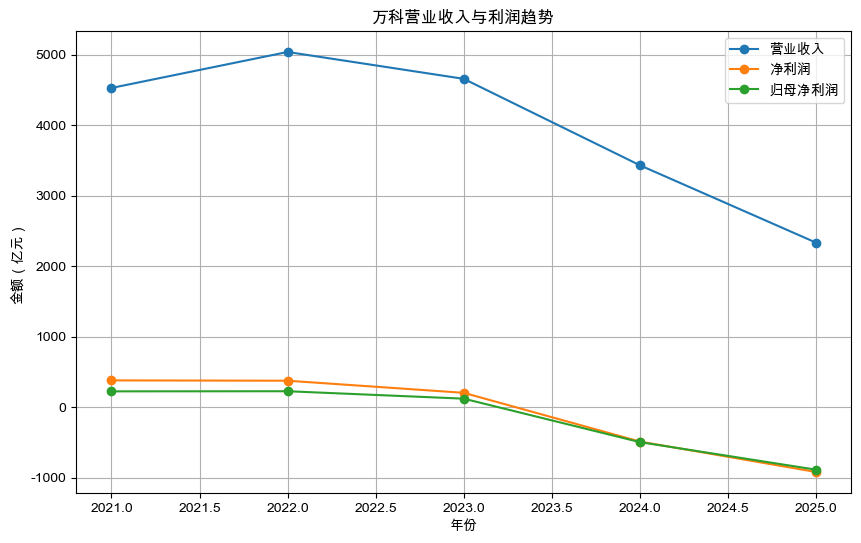

营业收入与利润趋势图已保存


In [14]:
# 营业收入与净利润趋势图

plt.figure(figsize=(10, 6))

plt.plot(财务分析结果["年份"], 财务分析结果["营业收入"], marker="o", label="营业收入")
plt.plot(财务分析结果["年份"], 财务分析结果["净利润"], marker="o", label="净利润")
plt.plot(财务分析结果["年份"], 财务分析结果["归母净利润"], marker="o", label="归母净利润")

plt.xlabel("年份")
plt.ylabel("金额（亿元）")
plt.title("万科营业收入与利润趋势")
plt.legend()
plt.grid(True)

plt.savefig("../charts/营业收入与利润趋势.png", dpi=300, bbox_inches="tight")
plt.show()

print("营业收入与利润趋势图已保存")

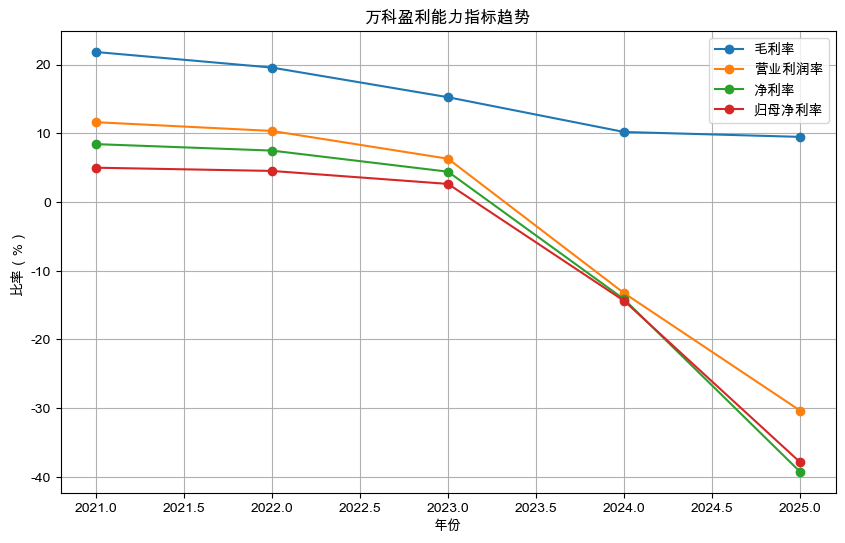

盈利能力指标趋势图已保存


In [15]:
# 利润率趋势图

plt.figure(figsize=(10, 6))

plt.plot(财务分析结果["年份"], 财务分析结果["毛利率"] * 100, marker="o", label="毛利率")
plt.plot(财务分析结果["年份"], 财务分析结果["营业利润率"] * 100, marker="o", label="营业利润率")
plt.plot(财务分析结果["年份"], 财务分析结果["净利率"] * 100, marker="o", label="净利率")
plt.plot(财务分析结果["年份"], 财务分析结果["归母净利率"] * 100, marker="o", label="归母净利率")

plt.xlabel("年份")
plt.ylabel("比率（%）")
plt.title("万科盈利能力指标趋势")
plt.legend()
plt.grid(True)

plt.savefig("../charts/盈利能力指标趋势.png", dpi=300, bbox_inches="tight")
plt.show()

print("盈利能力指标趋势图已保存")

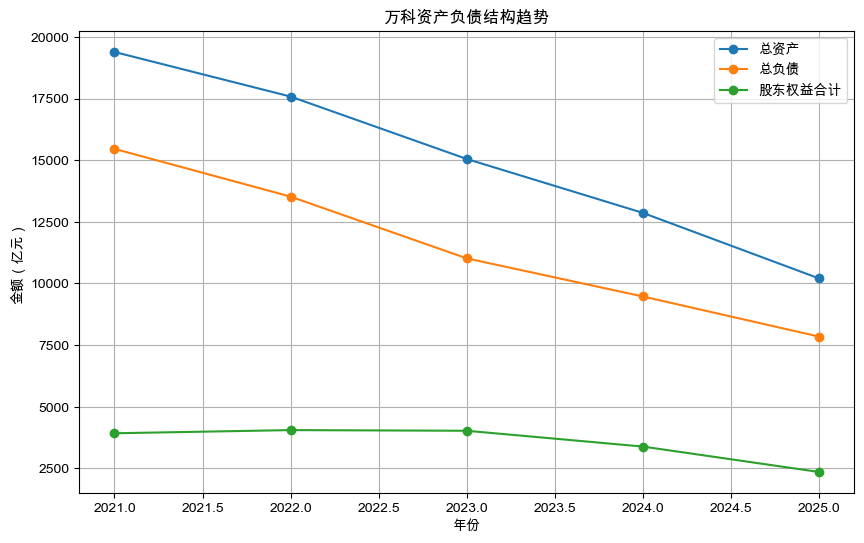

资产负债结构趋势图已保存


In [16]:
# 资产负债结构趋势图

plt.figure(figsize=(10, 6))

plt.plot(财务分析结果["年份"], 财务分析结果["总资产"], marker="o", label="总资产")
plt.plot(财务分析结果["年份"], 财务分析结果["总负债"], marker="o", label="总负债")
plt.plot(财务分析结果["年份"], 财务分析结果["股东权益合计"], marker="o", label="股东权益合计")

plt.xlabel("年份")
plt.ylabel("金额（亿元）")
plt.title("万科资产负债结构趋势")
plt.legend()
plt.grid(True)

plt.savefig("../charts/资产负债结构趋势.png", dpi=300, bbox_inches="tight")
plt.show()

print("资产负债结构趋势图已保存")

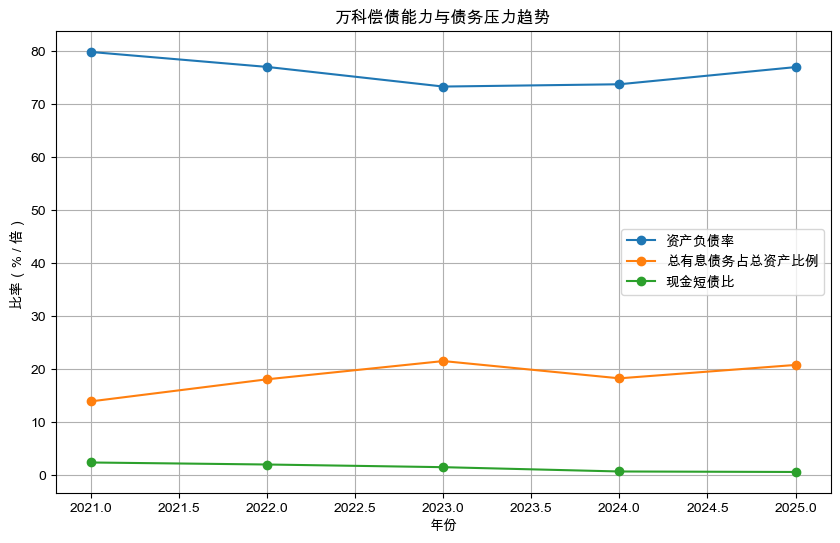

偿债能力与债务压力趋势图已保存


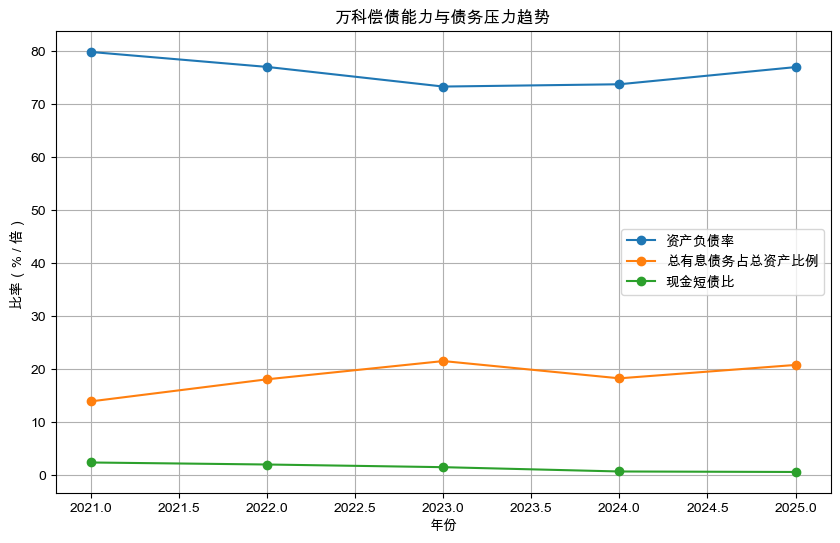

偿债能力与债务压力趋势图已保存


In [17]:
# 偿债能力与债务压力趋势图

plt.figure(figsize=(10, 6))

plt.plot(财务分析结果["年份"], 财务分析结果["资产负债率"] * 100, marker="o", label="资产负债率")
plt.plot(财务分析结果["年份"], 财务分析结果["总有息债务占总资产比例"] * 100, marker="o", label="总有息债务占总资产比例")
plt.plot(财务分析结果["年份"], 财务分析结果["现金短债比"], marker="o", label="现金短债比")

plt.xlabel("年份")
plt.ylabel("比率（% / 倍）")
plt.title("万科偿债能力与债务压力趋势")
plt.legend()
plt.grid(True)

plt.savefig("../charts/偿债能力与债务压力趋势.png", dpi=300, bbox_inches="tight")
plt.show()

print("偿债能力与债务压力趋势图已保存")# 偿债能力与债务压力趋势图

plt.figure(figsize=(10, 6))

plt.plot(财务分析结果["年份"], 财务分析结果["资产负债率"] * 100, marker="o", label="资产负债率")
plt.plot(财务分析结果["年份"], 财务分析结果["总有息债务占总资产比例"] * 100, marker="o", label="总有息债务占总资产比例")
plt.plot(财务分析结果["年份"], 财务分析结果["现金短债比"], marker="o", label="现金短债比")

plt.xlabel("年份")
plt.ylabel("比率（% / 倍）")
plt.title("万科偿债能力与债务压力趋势")
plt.legend()
plt.grid(True)

plt.savefig("../charts/偿债能力与债务压力趋势.png", dpi=300, bbox_inches="tight")
plt.show()

print("偿债能力与债务压力趋势图已保存")

In [18]:
# 自动生成财务分析 summary

最新年份 = 财务分析结果["年份"].max()
最早年份 = 财务分析结果["年份"].min()

最新数据 = 财务分析结果[财务分析结果["年份"] == 最新年份].iloc[0]
最早数据 = 财务分析结果[财务分析结果["年份"] == 最早年份].iloc[0]

# 提取关键指标
最新营业收入 = 最新数据["营业收入"]
最早营业收入 = 最早数据["营业收入"]

最新净利润 = 最新数据["净利润"]
最新归母净利润 = 最新数据["归母净利润"]

最新毛利率 = 最新数据["毛利率"] * 100
最新净利率 = 最新数据["净利率"] * 100
最新资产负债率 = 最新数据["资产负债率"] * 100
最新流动比率 = 最新数据["流动比率"]
最新现金短债比 = 最新数据["现金短债比"]
最新总有息债务占比 = 最新数据["总有息债务占总资产比例"] * 100

# 收入变化
收入变化率 = (最新营业收入 / 最早营业收入 - 1) * 100

summary_text = f"""
万科财务自动化分析总结（{最早年份}-{最新年份}）

一、收入与盈利表现
从{最早年份}年至{最新年份}，万科营业收入由{最早营业收入:.2f}亿元变化至{最新营业收入:.2f}亿元，累计变化幅度为{收入变化率:.2f}%。
{最新年份}年，公司净利润为{最新净利润:.2f}亿元，归母净利润为{最新归母净利润:.2f}亿元。

二、盈利能力
{最新年份}年，万科毛利率为{最新毛利率:.2f}%，净利率为{最新净利率:.2f}%。
如果利润率持续下降，说明公司盈利能力承压；如果利润率改善，则说明成本控制或利润质量有所提升。

三、资产负债与偿债能力
{最新年份}年，万科资产负债率为{最新资产负债率:.2f}%，流动比率为{最新流动比率:.2f}。
资产负债率反映公司整体杠杆水平，流动比率反映短期偿债能力。

四、债务与现金压力
{最新年份}年，万科现金短债比为{最新现金短债比:.2f}，总有息债务占总资产比例为{最新总有息债务占比:.2f}%。
现金短债比较低可能意味着短期偿债压力较大，而有息债务占比较高则说明公司对债务融资的依赖程度较高。

五、综合判断
本项目通过 Python 自动读取 Excel 财务数据，计算收入增长率、利润率、ROA、ROE、资产负债率、流动比率、现金短债比和有息债务占比等指标，并生成趋势图和分析文本。
该流程可以复用于其他上市公司，只需替换相同格式的 Excel 财务数据表，即可自动生成财务分析结果。
"""

print(summary_text)


万科财务自动化分析总结（2021-2025）

一、收入与盈利表现
从2021年至2025，万科营业收入由4527.98亿元变化至2334.33亿元，累计变化幅度为-48.45%。
2025年，公司净利润为-918.10亿元，归母净利润为-885.56亿元。

二、盈利能力
2025年，万科毛利率为9.46%，净利率为-39.33%。
如果利润率持续下降，说明公司盈利能力承压；如果利润率改善，则说明成本控制或利润质量有所提升。

三、资产负债与偿债能力
2025年，万科资产负债率为76.89%，流动比率为1.23。
资产负债率反映公司整体杠杆水平，流动比率反映短期偿债能力。

四、债务与现金压力
2025年，万科现金短债比为0.61，总有息债务占总资产比例为20.77%。
现金短债比较低可能意味着短期偿债压力较大，而有息债务占比较高则说明公司对债务融资的依赖程度较高。

五、综合判断
本项目通过 Python 自动读取 Excel 财务数据，计算收入增长率、利润率、ROA、ROE、资产负债率、流动比率、现金短债比和有息债务占比等指标，并生成趋势图和分析文本。
该流程可以复用于其他上市公司，只需替换相同格式的 Excel 财务数据表，即可自动生成财务分析结果。



In [19]:
# 保存自动生成的财务分析 summary

with open("../outputs/万科财务分析总结.txt", "w", encoding="utf-8") as f:
    f.write(summary_text)

print("万科财务分析总结已保存到 outputs/万科财务分析总结.txt")

万科财务分析总结已保存到 outputs/万科财务分析总结.txt


In [20]:
# 保存为 Excel 文件，包含原始财务数据和财务比率表

with pd.ExcelWriter("../outputs/万科财务分析结果汇总.xlsx", engine="openpyxl") as writer:
    财务分析结果.to_excel(writer, sheet_name="完整财务分析结果", index=False)
    财务比率表.to_excel(writer, sheet_name="核心财务比率表", index=False)

print("万科财务分析结果汇总 Excel 已保存")

万科财务分析结果汇总 Excel 已保存


In [21]:
import os

需要检查的文件夹 = [
    "../data/raw",
    "../data/processed",
    "../outputs",
    "../charts",
    "../notebooks"
]

for 文件夹 in 需要检查的文件夹:
    print("\n" + "="*60)
    print(文件夹)
    print("="*60)
    
    if os.path.exists(文件夹):
        for 文件 in os.listdir(文件夹):
            print(文件)
    else:
        print("文件夹不存在")


../data/raw
万科财务数据.xlsx
~$万科财务数据.xlsx

../data/processed
万科财务分析结果.csv

../outputs
万科财务分析结果汇总.xlsx
万科财务比率表.csv
万科财务分析总结.txt

../charts
资产负债结构趋势.png
偿债能力与债务压力趋势.png
营业收入与利润趋势.png
盈利能力指标趋势.png

../notebooks
.ipynb_checkpoints
financial_report_generator.ipynb.ipynb
